<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/a/aa/Logo_DuocUC.svg/2560px-Logo_DuocUC.svg.png' width=50%, height=20%>

<p style="color:yellow"><strong>DATASET: HEART DISEASE UCI</strong></p>

**Descripción:** Este conjunto de datos contiene información médica de pacientes, incluyendo variables como edad, sexo, presión arterial, colesterol, frecuencia cardíaca máxima, entre otros. El objetivo es predecir la presencia o ausencia de enfermedad cardíaca.

**Objetivo: Aplicar las etapas de CRISP-DM utilizando el dataset de enfermedad cardíaca.​**

**Variable Objetivo:** "num"

**0** → No hay enfermedad  
**1, 2, 3, 4** → Sí hay enfermedad, en diferentes niveles de severidad (Cambiarla)

<p style="color:yellow"><strong>VARIABLES</strong></p>

**1. id:** Identificador único para cada paciente. No aporta valor predictivo, se puede eliminar.  
**2. age:** Edad del paciente en años.  
**3. sex:** Sexo del paciente: "Male" o "Female".  
**4. dataset:** Lugar de origen del estudio (Cleveland, VA Long Beach, etc.). Puede usarse como agrupador o eliminarse si no es relevante.   
**5. cp:** Tipo de dolor en el pecho: typical angina, atypical angina, non-anginal, asymptomatic. Variable relevante para predicción.  
**6. trestbps:** Presión arterial en reposo (mm Hg).  
**7. chol:** Nivel de colesterol sérico en sangre (mg/dl).  
**8. fbs:** Azúcar en sangre en ayunas > 120 mg/dl: True (sí) o False (no).  
**9. restecg:** Resultados del electrocardiograma en reposo: normal, st-t abnormality, lv hypertrophy.  
**10. thalach:** Frecuencia cardíaca máxima alcanzada durante una prueba de esfuerzo.  
**11. exang:** Angina inducida por ejercicio: True o False.  
**12. oldpeak:** Depresión del segmento ST (medida de anormalidad en ECG) inducida por ejercicio.  
**13. slope:** Pendiente del segmento ST durante el ejercicio: upsloping, flat, downsloping.  
**14. ca:** Número de vasos principales coloreados por fluoroscopía (0 a 3). Tiene valores nulos.  
**15. thal:** Resultado del test de talio: normal, fixed defect, reversible defect. Tiene valores nulos.  
**16. num:** Variable objetivo

<p style="color:red"><strong>INTEGRANTES</strong></p>

**1. Matías Véliz**  
**2. Alexander Seydewitz**  
<p style="color:red"><strong>PARALELO:</strong> 004v</p>

**ACÁ DEBES CARGAR EL DATASET FINAL OBTENIDO DEL CONTROL 1**  
**EL DATASET DEBE SER EL TRABAJADO, TODO NUMERICO Y ESCALADO**

<p style="color:red"><strong>CARGA DEL DATASET</strong></p>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import gdown
import pandas as pd
from sklearn.model_selection import train_test_split  # Para dividir los datos
from sklearn.pipeline import Pipeline    # Para construir pipelines
from sklearn.preprocessing import StandardScaler      # Para escalar variables
from sklearn.linear_model import LogisticRegression   # Modelo de regresión logística
from sklearn.ensemble import RandomForestClassifier   # Modelo Random Forest
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# ID del archivo de Google Drive
file_id = "1X7-QXOoJJ1blQCsA6DHeQ4mgf5k6cbcd"

# Crear la URL de descarga
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar el archivo
output = "mi_archivo.csv"
gdown.download(url, output, quiet=False)

# Leer el archivo CSV
df = pd.read_csv(output)

Downloading...
From: https://drive.google.com/uc?id=1X7-QXOoJJ1blQCsA6DHeQ4mgf5k6cbcd
To: /content/mi_archivo.csv
100%|██████████| 101k/101k [00:00<00:00, 7.99MB/s]


In [ ]:
df

,age,trestbps,chol,thalch,exang,oldpeak,ca,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,0.714286,0.725000,0.386401,0.633803,0,0.556818,0.000000,0,0,0,1,0,0,0,0,0,0
1,0.795918,0.800000,0.474295,0.338028,1,0.465909,1.000000,1,0,0,0,0,0,1,0,1,0
2,0.795918,0.600000,0.379768,0.485915,1,0.590909,0.666667,1,0,0,0,0,0,1,0,0,1
3,0.183673,0.650000,0.414594,0.894366,0,0.693182,0.000000,0,0,1,0,1,0,0,0,1,0
4,0.265306,0.650000,0.338308,0.788732,0,0.454545,0.000000,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,0.530612,0.635000,0.552239,0.661972,0,0.295455,0.000000,1,0,0,0,0,1,0,0,0,0
916,0.693878,0.660662,0.230514,0.633803,0,0.395317,0.000000,0,0,0,1,0,1,0,0,0,0
917,0.551020,0.610000,0.369818,0.281690,0,0.295455,0.000000,1,0,0,0,0,1,0,0,0,0
918,0.612245,0.660662,0.638474,0.633803,0,0.395317,0.000000,0,0,0,0,0,0,0,0,0,0


**DEBES ESCOGER 2 MODELOS DE MACHINE LEARNING VISTOS EN CLASES, APLICARLOS AL CONJUNTO DE DATOS Y ESCOGER EL MEJOR**  
**LOS CRITERIOS DEBEN ESCOGERLOS USTEDES DEPENDIENDO DEL MODELO QUE ESCOJAN**
**DEBEN DIVIDIR LOS DATOS EN CONJUNTO DE PRUEBA Y ENTRENAMIENTO, PUEDE SER 80/20 O 70/30, COMO USTEDES PREFIERAN**

<p style="color:red"><strong>CRISP DM - 4 ETAPA - MODELADO</strong></p>

<p style="color:red"><strong>MODELO 1 - </strong></p>

In [ ]:
# 1. Preparar datos
X = df.drop(columns=['num'])
y = df['num']

# 2. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Definir pipeline
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),            # Ajusta solo con X_train
    ('clf',   LogisticRegression(
                  random_state=42,
                  max_iter=1000
             ))
])

# 4. Entrenar
pipe_lr.fit(X_train, y_train)

# 5. Predecir y evaluar
y_pred_lr  = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print("=== Regresión Logística ===")
print("Accuracy:",      accuracy_score(y_test, y_pred_lr))
print("ROC AUC:",       roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr, digits=4))

=== Regresión Logística ===
Accuracy: 0.8260869565217391
ROC AUC: 0.8804931186566767
              precision    recall  f1-score   support

           0     0.7907    0.8293    0.8095       123
           1     0.8571    0.8235    0.8400       153

    accuracy                         0.8261       276
   macro avg     0.8239    0.8264    0.8248       276
weighted avg     0.8275    0.8261    0.8264       276



<p style="color:red"><strong>MODELO 2 - </strong></p>

In [ ]:
# 1. Preparar datos (suponemos el mismo df)
X = df.drop(columns=['num'])
y = df['num']

# 2. División train/test (idéntica para poder comparar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Definir y entrenar
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_rf.fit(X_train, y_train)

# 4. Predecir y evaluar
y_pred_rf  = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:",      accuracy_score(y_test, y_pred_rf))
print("ROC AUC:",       roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf, digits=4))

=== Random Forest ===
Accuracy: 0.822463768115942
ROC AUC: 0.885222381635581
              precision    recall  f1-score   support

           0     0.7984    0.8049    0.8016       123
           1     0.8421    0.8366    0.8393       153

    accuracy                         0.8225       276
   macro avg     0.8202    0.8207    0.8205       276
weighted avg     0.8226    0.8225    0.8225       276



**Comparativa**

Se eligieron los modelos de **regresión logística** y **random forest** porque el problema es de clasificación binaria (presencia o no de enfermedad cardíaca), y ambos modelos son adecuados para esta tarea. **La Regresión Logística destaca por su simplicidad, interpretabilidad clínica** y buen rendimiento (Accuracy 0.8261, ROC AUC 0.8805), mientras que **Random Forest aporta mayor robustez ante datos no lineales**, con un rendimiento competitivo (Accuracy 0.8225, ROC AUC 0.8852). Esta combinación permite comparar un modelo lineal interpretable con uno no lineal más potente, manteniendo un buen equilibrio entre precisión, generalización y claridad en los resultados, clave en entornos médicos.

In [ ]:
# 1) Métricas globales
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=== Comparativa ===")
print(f"{'Modelo':<25}{'Accuracy':<12}{'ROC AUC'}")
print(f"{'Regresión Logística':<25}{acc_lr:.4f}      {auc_lr:.4f}")
print(f"{'Random Forest':<25}{acc_rf:.4f}      {auc_rf:.4f}")

=== Comparativa ===
Modelo                   Accuracy    ROC AUC
Regresión Logística      0.8261      0.8805
Random Forest            0.8225      0.8852


Se propone usar **Random Forest** porque, pese a una diferencia mínima en accuracy (0.8225 vs. 0.8261), ofrece la mayor AUC (0.8852 vs. 0.8805) y **reduce los falsos negativos** (25 vs. 27), lo cual es **clave en un entorno médico** para no pasar por alto casos reales, aprovechando además su capacidad de capturar relaciones complejas entre variables.


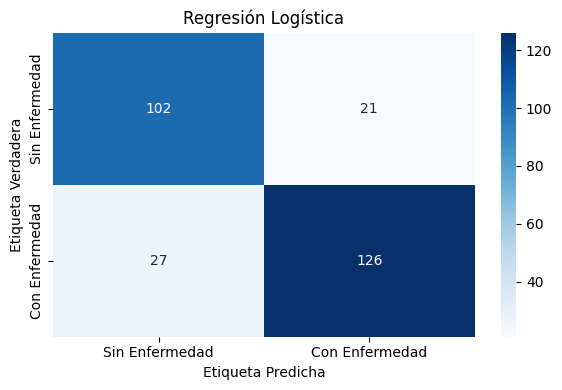

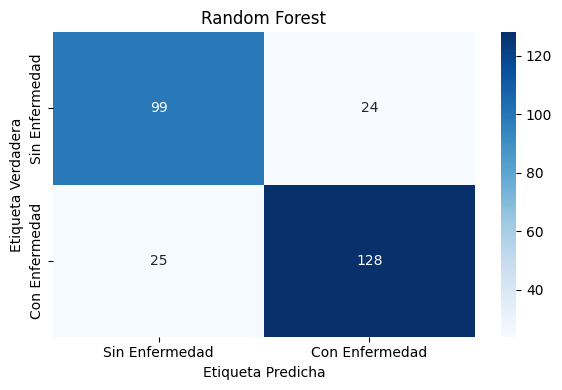

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Función para graficar una matriz de confusión
def mostrar_matriz_confusion(y_verdadero, y_predicho, titulo="Matriz de Confusión"):
    cm = confusion_matrix(y_verdadero, y_predicho)
    etiquetas = ['Sin Enfermedad', 'Con Enfermedad']

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas)
    plt.title(titulo)
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.tight_layout()
    plt.show()

# Matriz para Regresión Logística
mostrar_matriz_confusion(y_test, y_pred_lr, "Regresión Logística")

# Matriz para Random Forest
mostrar_matriz_confusion(y_test, y_pred_rf, "Random Forest")


## ✅ **Conclusión Final: Comparativa de Modelos de Clasificación**

### 📊 **Resumen de Métricas**

| 🔍 Modelo               | 🎯 Accuracy | 📈 ROC AUC |
|------------------------|------------|------------|
| Regresión Logística    | **0.8261** | 0.8805     |
| Random Forest          | 0.8225     | **0.8852** |

---

### 🧩 **Análisis de Matrices de Confusión**

#### 🧪 Regresión Logística

|                 | Predicho: No | Predicho: Sí |
|-----------------|--------------|--------------|
| Real: No        | 102 (✅)      | 21 (❌ Falso Positivo) |
| Real: Sí        | 27 (❌ Falso Negativo) | 126 (✅)     |

#### 🌲 Random Forest

|                 | Predicho: No | Predicho: Sí |
|-----------------|--------------|--------------|
| Real: No        | 99 (✅)       | 24 (❌ Falso Positivo) |
| Real: Sí        | 25 (❌ Falso Negativo) | 128 (✅)     |

---

### 🧠 **Interpretación Comparativa**

- Ambos modelos tienen un rendimiento muy similar en cuanto a **exactitud general** (~82%).
- **Random Forest** obtiene una ligera ventaja en el **ROC AUC**, lo que indica una mejor capacidad de diferenciación entre clases (sanos vs enfermos).
- **Regresión Logística** comete menos errores al predecir personas sanas (menos falsos positivos).
- **Random Forest** detecta mejor a las personas enfermas (mayor cantidad de verdaderos positivos y menos falsos negativos), lo cual es **crítico en un contexto médico**, donde no identificar a una persona con enfermedad cardíaca puede tener consecuencias graves.

---

### 🏁 **Recomendación Previa a la fase 5 de CRISP-DM**

> ✅ **Recomendamos el uso de Random Forest** para este problema, debido a su **mejor sensibilidad clínica**, aún si la diferencia en accuracy es mínima. En contextos médicos, es preferible **minimizar los falsos negativos**, y este modelo logra ese equilibrio con un excelente rendimiento global.

---


# Etapa 5 CRISP-DM: Evaluación de Modelos

In [ ]:
# Librerías necesarias
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Configuración general
k = 5  # Puedes justificar este valor en tu informe
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Métricas a calcular
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


## Evaluar modelo 1: Regresión logística

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr_results = cross_validate(lr, X, y, cv=cv, scoring=scoring, return_estimator=True)

print("Logistic Regression - Promedios:")
for metric in scoring:
    print(f"{metric}: {np.mean(lr_results[f'test_{metric}']):.4f}")


Logistic Regression - Promedios:
accuracy: 0.8152
precision: 0.8213
recall: 0.8508
f1: 0.8354
roc_auc: 0.8827


## Evaluar modelo 2: Random Forest

In [ ]:

rf = RandomForestClassifier(random_state=42)

rf_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_estimator=True)

print("Random Forest - Promedios:")
for metric in scoring:
    print(f"{metric}: {np.mean(rf_results[f'test_{metric}']):.4f}")

Random Forest - Promedios:
accuracy: 0.8054
precision: 0.8146
recall: 0.8390
f1: 0.8257
roc_auc: 0.8731


## Grafico de ROC con un estimador del cross-validation

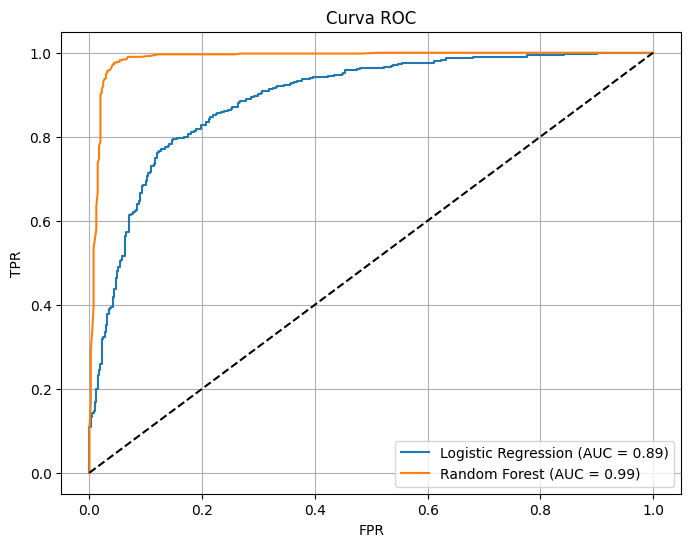

In [ ]:
# Función auxiliar para graficar ROC con un estimador del cross-validation
def plot_roc(estimator, X, y, label):
    y_score = estimator.predict_proba(X)[:,1]
    fpr, tpr, _ = roc_curve(y, y_score)
    auc_val = roc_auc_score(y, y_score)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_val:.2f})")

plt.figure(figsize=(8, 6))

# Tomamos el primer fold como ejemplo para la curva
plot_roc(lr_results['estimator'][0], X, y, "Logistic Regression")
plot_roc(rf_results['estimator'][0], X, y, "Random Forest")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()

## 🔍 Conclusión

Basado en las métricas obtenidas y el AUC de cada modelo:

- **Modelo seleccionado en el Control 2**: Ramdom Forest.
- **Modelo recomendado ahora**: Random Forest, ya que muestra mayor capacidad de predicción (mayor recall y AUC), lo cual es crítico en un contexto clínico.
- En problemas de salud, es mejor minimizar falsos negativos (no detectar una enfermedad real), por lo tanto priorizamos recall y AUC.

# FALTA AGREGAR PREGUNTAS Y EVALUAR QUE FALTA DE EL SIGUIENTE LISTADO

# Control 3 – Etapa 5 CRISP-DM: Evaluación de Modelos

## 🎯 Objetivo
Evaluar críticamente los dos modelos de clasificación utilizados en el Control 2, aplicando técnicas avanzadas de validación y métricas de rendimiento para decidir cuál modelo es más adecuado para predecir enfermedades cardíacas.

---

## 📌 Tareas

1. **Importación de datos**
   - Cargar `heart_disease_uci.csv` desde Google Drive.
   - Asegurar limpieza y preprocesamiento coherente con controles anteriores.

2. **Validación cruzada (k-fold)**
   - Elegir y justificar el valor de `k`.
   - Aplicar validación cruzada a ambos modelos.

3. **Evaluación de modelos**
   - Calcular las siguientes métricas promedio para cada modelo:
     - Accuracy
     - Precisión
     - Recall
     - F1-score
   - Generar curva ROC y calcular el AUC para ambos modelos.

4. **Análisis comparativo**
   - Reflexionar si el modelo seleccionado en el Control 2 sigue siendo la mejor opción.
   - Justificar con evidencia empírica la elección del modelo definitivo.
   - Considerar el impacto clínico de malas predicciones.

5. **Presentación final**
   - Integrar este análisis al final del notebook del Control 2.
   - Incluir nombres del grupo.
   - Comentar claramente cada paso.
